<h1>ML модель AutoValue предсказания стоимости автомобиля с минимизацией утеренной прибыли</h1>

<h3>1. Цели и задачи проекта</h3>

<h3>1.1. Цель:</h3>
<p>
Разработать модель предсказания стоимости автомобиля, которая оценивает стоимость автомабиля по следам совершенных сделок с минимизацией рисков 
</p>

<h3>1.2. Задача:</h3>
<p>Построить модель для решения задачи регрессии, которая прогнозирует цену автомобиля, минимизируя долю сделок с отклонением >20% в обе стороны </p>
<h3>1.3. План работы</h3>
<ul>
    <li>Этап 1. Подготовка среды: загрузка данных, фиксация random_state, установка библиотек.</li>
    <li>Этап 2. Анализ данных (EDA): изучаем таблицы с тестовыми и тренировочными данными, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками</li>
    <li>Этап 3. Базовые модели: обучаем XGBoost, CatBoost и LightGBM дополнительно рассмотрим их время обучения</li>
    <li>Этап 4. Гиперпараметры: Подбираем гиперпараметры используя Optuna</li>
    <li>Этап 5. Интерпретация и бизнес-анализ: проверяем основные признаки для предсказания используя SHAP, проверяем обосновано ли влияние признаков на target, сверяем ошибки модели с конкретными категориями машин</li>
    <li>Этап 6. Финальная проверка тестируем модель на тестовых данных проверяем выполняются ли критерии заказчика</li>
    <li>Этап 7. Отчёт: фиксируем итоговые параметры модели, оцениваем важность признаков, формулируем выводы и рекомендации по дальнейшей работе модели</li>
</ul>

<h3>2. Перевод бизнес-задачи на язык машинного обучения</h3>
<p>
Бизнес-задача находить примерную стоимость автомобиля, минимизируя риски переплат и упущенной выгоды. 
Это задача регрессии с минимизацией доли объектов, у которых ошибка предсказания превышает 20% в обе сотроны
</p>
<p>
Для решения задачи будут использованы модели бустинга из 3 библиотек: XGBoost, CatBoost и LightGBM. 
Для каждой библиотеки будут подобраны подходящие пайплайны предобработки признаков и гиперпараметры.
</p>
<p>Технические метрики:</p>
<ul>
    <li>MAE - основная метрика показывает среднюю ошибку прогноза</li>
    <li>RMSE - сильнее штрафует за крупные отклонения засчёт возведения в квадрат</li>
    <li>MSE - вспомогательная метрика, используется как функция потерь </li>
    <li>R² - показывает, какую долю дисперсии target объясняет модель</li>
</ul>
<p>Бизнес-метрики:</p>
<ul>
    <li>Overpricing Rate - доля сделок, где модель завысила цену более чем на 20% </li>
    <li>Underpricing Loss - упущенная выгода по сделкам, где модель занизила цену более чем на 20%</li>
</ul>

<h2>Этап 1. Подготовка среды: загрузка данных, фиксация random_state, установка библиотек</h2>
<ul>
    <li>Установим и настроим библиотеки</li>
    <li>Зафиксируем <code>random_state</code> и параметры отображения</li>
    <li>Загрузим данные из CSV-файлов</li>
</ul>

In [1]:
!pip install phik -q
!pip install optuna -q
!pip install shap -q
!pip install xgboost catboost lightgbm -q

import numpy as np
import pandas as pd
import phik
import optuna
import time
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_validate, cross_val_predict, cross_val_score, KFold)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, make_scorer)

import xgboost as xgb
from xgboost import XGBRegressor

import catboost as cb
from catboost import CatBoostRegressor, Pool

import lightgbm as lgb
from lightgbm import LGBMRegressor

import shap
from sklearn.tree import plot_tree


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h3>Зафиксируем <code>random_state</code> и параметры отображения</h3>

In [2]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

<ul>
    <li><code>plt.style.use('default')</code> - использование стандартного стиля визуализации matplotlib.</li>
    <li><code>plt.rcParams['figure.figsize'] = (10, 6)</code> - размер графиков.</li>
    <li><code>plt.rcParams['font.size'] = 12</code> - размер шрифта на графиках.</li>
    <li><code>RANDOM_STATE = 42</code> - фиксация генератора случайных чисел для воспроизводимости результатов.</li>
</ul>

<h3>Загрузим данные из CSV-файлов:</h3>
<ul>
    <li>ds_s16_train_data.csv</li>
    <li>ds_s16_test_data.csv</li>
</ul>

In [3]:
try:
    train = pd.read_csv('ds_s16_train_data.csv')
    test = pd.read_csv('ds_s16_test_data.csv')
except:
    train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_train_data.csv')
    test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_test_data.csv')

In [4]:
datasets = {
    'train': train,
    'test': test,
}

for name, df in datasets.items():
    print(f'{name}: {df.shape}')

train: (8000, 13)
test: (2000, 13)


<p><b>Среда разработки поготовлена, данные выгружены. Переходим к EDA </b></p>

<h2>Этап 2. Анализ данных (EDA): изучаем таблицы с тестовыми и тренировочными данными, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками</h2>

<h3>Первичный анализ выгруженных данных</h3>

In [5]:
def datasets_info(datasets):
    for name, df in datasets.items():
        print(name)
        
        for col in df.columns:
            print(f"\t{col}"
                  f"\n\t\tтип: {df[col].dtype}"
                  f"\n\t\tвсего строк: {len(df[col])}"
                  f"\n\t\tпропусков: {df[col].isna().sum()}"
                  f"\n\t\tуникальных значений: {len(list(df[col].dropna().unique()))}"
                  f"\n\t\tпримеры возможных значений: {list(df[col].dropna().unique()[:5])}")
        print()
datasets_info(datasets)

train
	make_year
		тип: int64
		всего строк: 8000
		пропусков: 0
		уникальных значений: 29
		примеры возможных значений: [np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2019), np.int64(2015)]
	mileage_kmpl
		тип: float64
		всего строк: 8000
		пропусков: 0
		уникальных значений: 2108
		примеры возможных значений: [np.float64(9.7), np.float64(16.1), np.float64(10.51), np.float64(14.27), np.float64(21.72)]
	engine_cc
		тип: int64
		всего строк: 8000
		пропусков: 0
		уникальных значений: 10
		примеры возможных значений: [np.int64(1800), np.int64(1500), np.int64(5000), np.int64(2000), np.int64(1000)]
	fuel_type
		тип: str
		всего строк: 8000
		пропусков: 0
		уникальных значений: 3
		примеры возможных значений: ['Diesel', 'Petrol', 'Electric']
	owner_count
		тип: int64
		всего строк: 8000
		пропусков: 0
		уникальных значений: 5
		примеры возможных значений: [np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(4)]
	brand
		тип: str
		всего строк: 8000
		пропусков: 0
		уника

<h4>Выводы по первичному анализу данных</h4>
<ul>
    <li>Явных пропусков нет</li>
    <li>Распределение train/test соответствует заявленным 80/20</li>
    <li>Количетво уникальных значений в категориальных признаках совпадает, нужно проверить что все возможные значения действительно есть в обоих датасетах</li>
</ul>

<h4>Гипотезы для проверки</h4>
<ul>
    <li>признаки <code>make_year</code> и <code>brend</code> могут иметь линейную связь с целевой переменной</li>
    <li>признак <code>mileage_kmpl</code> может содержать много объектов со значениями 5-8 следует проверить, как зависит от пробега цена машины</li>
    <li>признак <code>mileage_kmpl</code> можно сильно коррелировать с <code>make_year</code> <code>owner_count</code></li>
    <li>признаки <code>engine_cc</code> <code>fuel_type</code> <code>transmission</code> показывают характеристики машины, поэтому напрямую объясняют цену из-за затрат на достижение этих характеристик</li>
    <li>признаки <code>accidents_reported</code> <code>brand</code> <code>color</code> показывают цену с точки зрения поведения клиента(более популярный бренд редкий цвет и.т.д.)</li>
</ul>

<h3>Распределение целевой переменной</h3>


Выборка: train
Распределение:
count    8.000000e+03
mean     6.836479e+05
std      2.649235e+05
min      9.500000e+04
25%      4.938570e+05
50%      6.638660e+05
75%      8.550560e+05
max      1.676525e+06
Name: price_rub, dtype: float64
Выбросы:
Количество: 45
Процент: 0.56
Границы: -47941.5 1396854.5
Первые 5 выбросов выше верхней границы: [1400366 1403016 1406533 1407712 1410052]
5 максимальных значений: [1598505 1609832 1619217 1652568 1676525]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


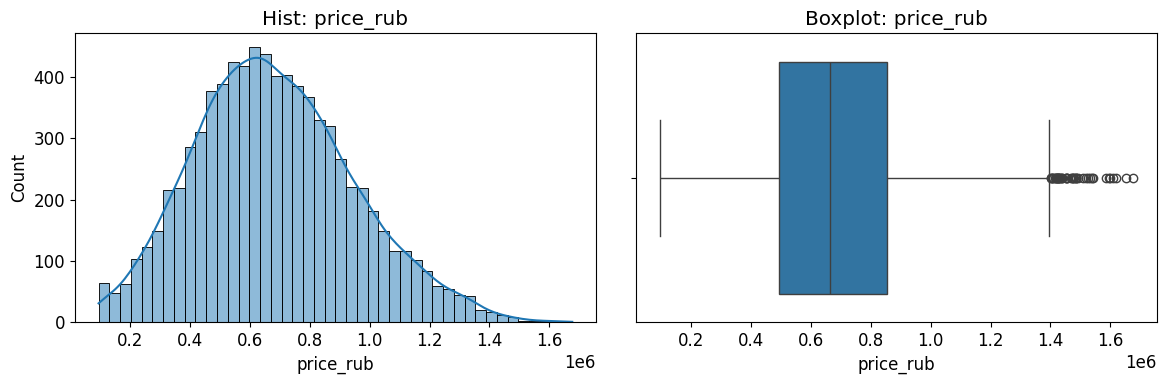



Выборка: test
Распределение:
count    2.000000e+03
mean     6.757919e+05
std      2.680196e+05
min      9.500000e+04
25%      4.814770e+05
50%      6.492840e+05
75%      8.459695e+05
max      1.629774e+06
Name: price_rub, dtype: float64
Выбросы:
Количество: 13
Процент: 0.65
Границы: -65261.75 1392708.25
Первые 5 выбросов выше верхней границы: [1402684 1404272 1412528 1420397 1422675]
5 максимальных значений: [1485049 1592142 1592682 1604212 1629774]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


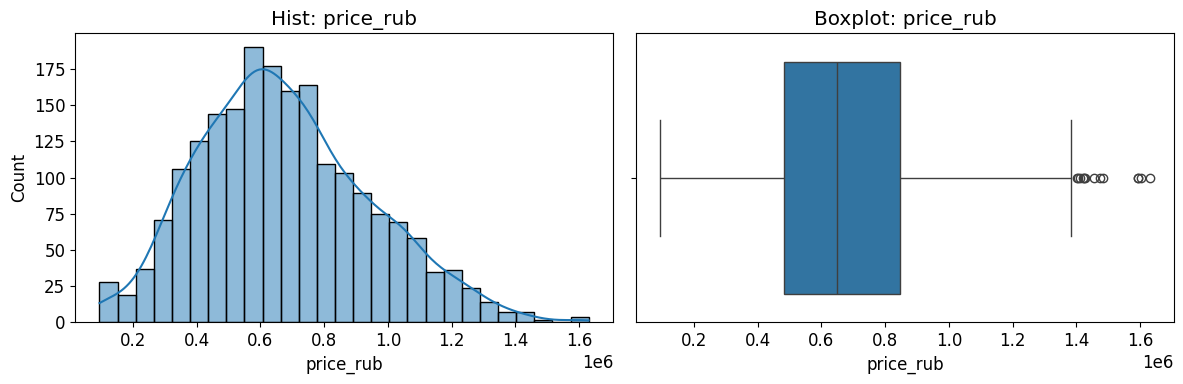

In [6]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    low_outliers = data[data < lower_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers) / len(data) * 100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы:", high_outliers.head(5).values)
    print("5 максимальных значений:", high_outliers.tail(5).values)
    print("Первые 5 выбросов ниже нижней границы:", low_outliers.tail(5).values)
    print("5 минимальных значений:", low_outliers.head(5).values)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data, kde=True, ax=axes[0])
    axes[0].set_title(f"Hist: {col}")
    sns.boxplot(x=data, ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    print('Выборка:', name)
    print('Распределение:')
    data_review(df, 'price_rub')
    print('\n')

<h4>Вывод по распределению целевой переменной</h4>
<p>
По describe данные по процентилям совпадают с высокой точностью. Пропорционально доле выборки (1/4) соответствует распределение выбросов, и примерные их значения совпадают, так что целевая переменная имеет одинаковое распределение в train и test
<p>
Распределение близкое к нормальному с небольшой правосторонней асимметрией и небольшим количеством выбросов, не сильно превышающих порог по IQR, что в целом реально соответствует дорогим машинам аномалий по target нет. Выбросов ниже нижней границы нет
</p>
<p>
Общий вывод по распределению целевой переменной: проблем нет, переходим к анализу дубликатов
</p>

<h3>Анализ дубликатов</h3>

In [7]:
def duplicates_report(df, id_col=None):
    full_dup = df.duplicated().sum()
    print("Полные дубликаты строк:", full_dup)
    
    if id_col is not None and id_col in df.columns:
        id_dup = df.duplicated(subset=[id_col]).sum()
        print(f"Дубликаты по {id_col}: {id_dup}")
        no_id = df.drop(columns=[id_col])
        no_id_dup = no_id.duplicated().sum()
        print(f"Дубликаты без {id_col}: {no_id_dup}")

for name, df in datasets.items():
    print(name)
    duplicates_report(df, 'price_rub')
    print("\n")

train
Полные дубликаты строк: 0
Дубликаты по price_rub: 71
Дубликаты без price_rub: 0


test
Полные дубликаты строк: 0
Дубликаты по price_rub: 16
Дубликаты без price_rub: 0




<h4>Вывод по проверке дубликатов</h4>
<p>
Полных дубликатов строк нет. При проверке дубликатов без учёта price_rub также не найдено дублитов значит, изменение любой другой колонки (кроме цены) 
означает другую сделку. Не хватает идентификатора конкретной машины или сделки, поэтому невозможно достоверно определить неявные дубликаты по одной и той же машине или сделке так как нет способа отличить две разные, но похожие по характеристикам машины от одной и той же машины
</p>
<p>
Итог: явных и полных дубликатов в данных нет переходим к обработке категориальных значений
</p>

<h3>Обработка категориальный значений</h3>

In [8]:
def categorical_analysis(df, cat_cols):
    for col in cat_cols:
        print("Столбец:", col)
        print("Уникальных значений:", df[col].nunique())
        print("Примеры значений:", df[col].unique()[:10])
        print()

cat_cols = ['brand', 'fuel_type', 'transmission', 'color', 'service_history', 'insurance_valid', 'region']

for name, df in datasets.items():
    cols = [col for col in cat_cols if col in df.columns]

    if cols:
        print(name, "\n")
        categorical_analysis(df, cols)
        print("\n")

train 

Столбец: brand
Уникальных значений: 10
Примеры значений: <StringArray>
[   'Hyundai',       'Ford',     'Toyota',     'Nissan',        'Kia',
      'Tesla',        'BMW',      'Honda', 'Volkswagen',  'Chevrolet']
Length: 10, dtype: str

Столбец: fuel_type
Уникальных значений: 3
Примеры значений: <StringArray>
['Diesel', 'Petrol', 'Electric']
Length: 3, dtype: str

Столбец: transmission
Уникальных значений: 2
Примеры значений: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

Столбец: color
Уникальных значений: 6
Примеры значений: <StringArray>
['Silver', 'Black', 'Gray', 'White', 'Blue', 'Red']
Length: 6, dtype: str

Столбец: service_history
Уникальных значений: 3
Примеры значений: <StringArray>
['Partial', 'Unknown', 'Full']
Length: 3, dtype: str

Столбец: insurance_valid
Уникальных значений: 2
Примеры значений: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Столбец: region
Уникальных значений: 6
Примеры значений: <StringArray>
['Урал', 'Москва', 'Юг', 'Дальний 

<h4>Вывод по анализу категориальных признаков</h4>
<p>
Значения категорий в train и test совпадают(модель не встретит незнакомую категорию в тесте)Максимальное количество уникальных значений в brand - 10
</p>
<p>
Так как все три библиотеки бустинга в проекте имеют встроенный кодировщик категорий (включая XGBoost с версии 1.6), а в признаках нет высокой кардинальности (решение в лоб подойдёт), OHE через трансформер не требуется достаточно явно задать тип category для всех столбцов 
</p>

In [9]:
for name, df in datasets.items():
    for col in cat_cols:
        df[col] = df[col].astype('category')
for name, df in datasets.items():
    print(name)
    print(df[cat_cols].dtypes)
    print()

train
brand              category
fuel_type          category
transmission       category
color              category
service_history    category
insurance_valid    category
region             category
dtype: object

test
brand              category
fuel_type          category
transmission       category
color              category
service_history    category
insurance_valid    category
region             category
dtype: object



<h3>Анализ выбросов и распределления</h3>



 train 

Столбец:  make_year 

count    8000.000000
mean     2009.221250
std         8.388703
min      1995.000000
25%      2002.000000
50%      2009.000000
75%      2017.000000
max      2023.000000
Name: make_year, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: 1979.5 2039.5
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


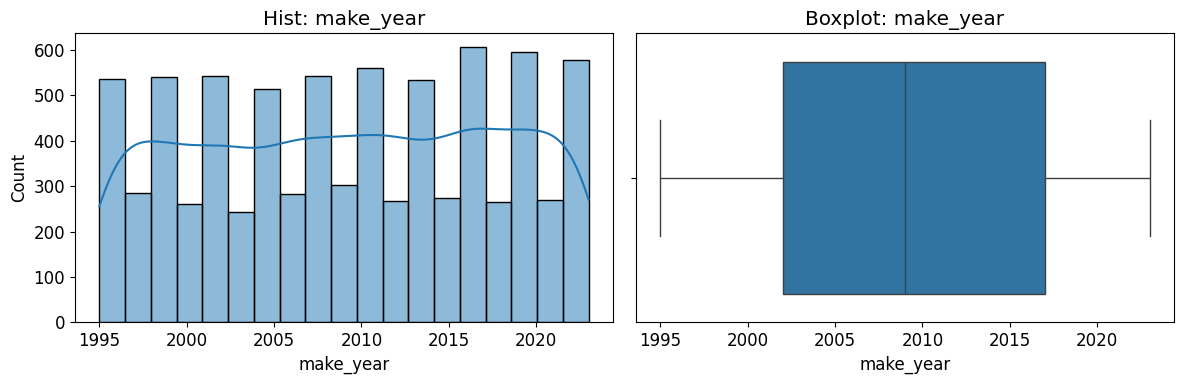

Столбец:  mileage_kmpl 

count    8000.000000
mean       17.946343
std         5.015565
min         5.000000
25%        14.530000
50%        17.970000
75%        21.350000
max        35.000000
Name: mileage_kmpl, dtype: float64
Выбросы:
Количество: 27
Процент: 0.34
Границы: 4.3 31.58
Первые 5 выбросов выше верхней границы: [31.61 31.72 31.81 31.84 31.93]
5 максимальных значений: [33.75 34.2  34.5  34.99 35.  ]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


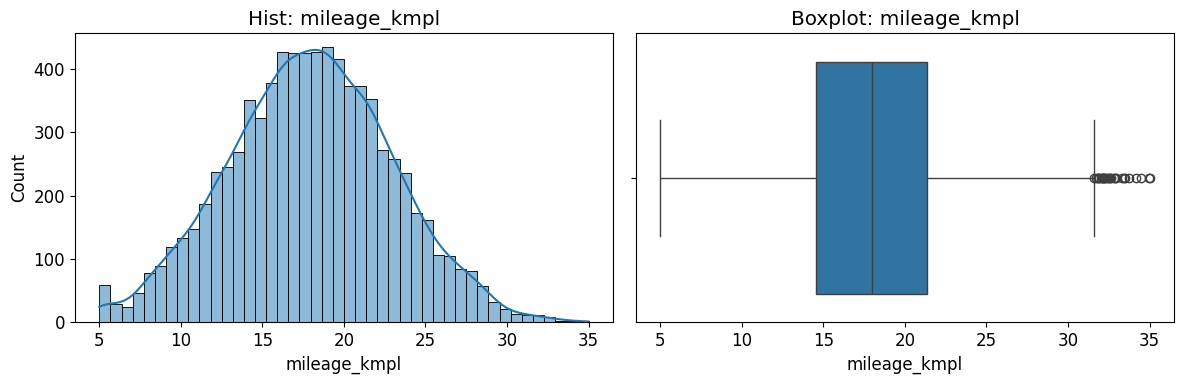

Столбец:  engine_cc 

count    8000.000000
mean     2289.687500
std      1289.812139
min       800.000000
25%      1200.000000
50%      2000.000000
75%      3000.000000
max      5000.000000
Name: engine_cc, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -1500.0 5700.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


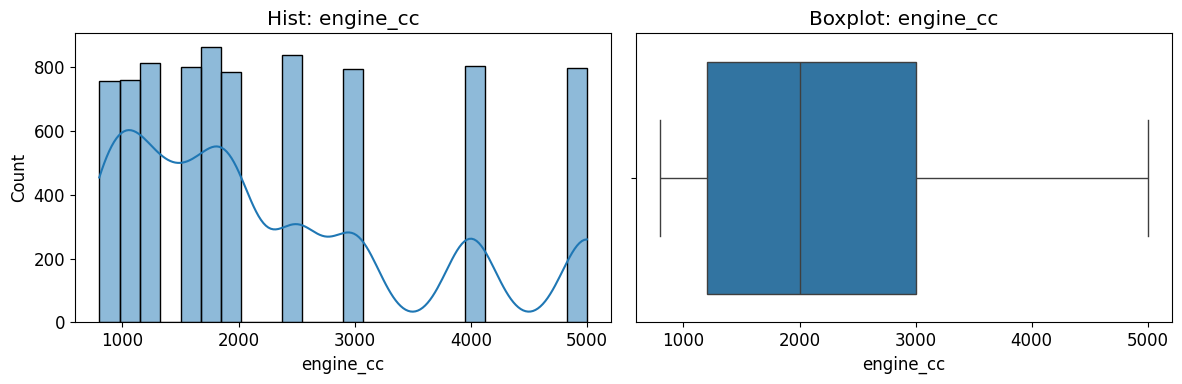

Столбец:  owner_count 

count    8000.000000
mean        3.001125
std         1.419199
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: owner_count, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -1.0 7.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


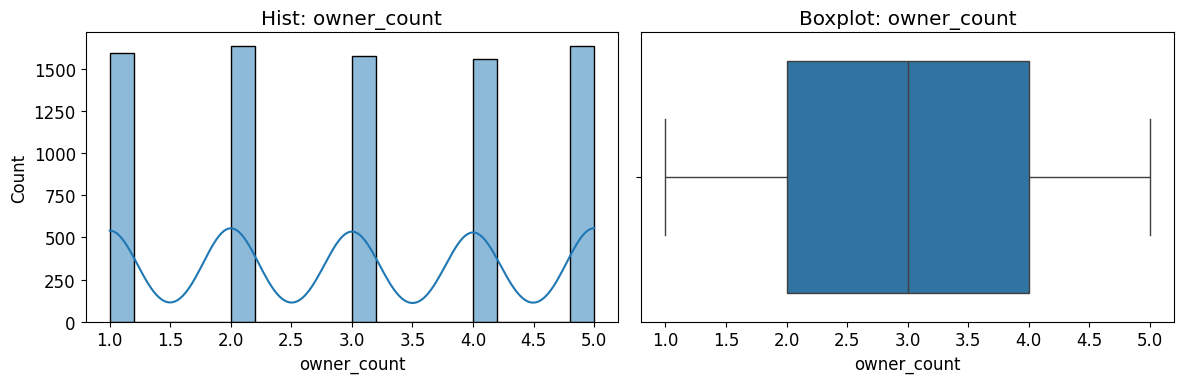

Столбец:  accidents_reported 

count    8000.000000
mean        0.487875
std         0.693839
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         5.000000
Name: accidents_reported, dtype: float64
Выбросы:
Количество: 103
Процент: 1.29
Границы: -1.5 2.5
Первые 5 выбросов выше верхней границы: [3 3 3 3 3]
5 максимальных значений: [4 4 4 5 5]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


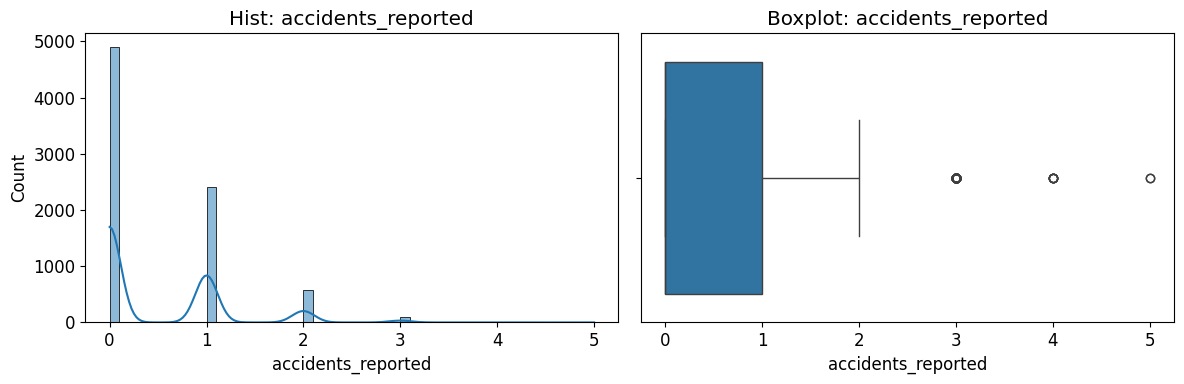



 test 

Столбец:  make_year 

count    2000.000000
mean     2009.149500
std         8.316052
min      1995.000000
25%      2002.000000
50%      2009.000000
75%      2016.000000
max      2023.000000
Name: make_year, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: 1981.0 2037.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


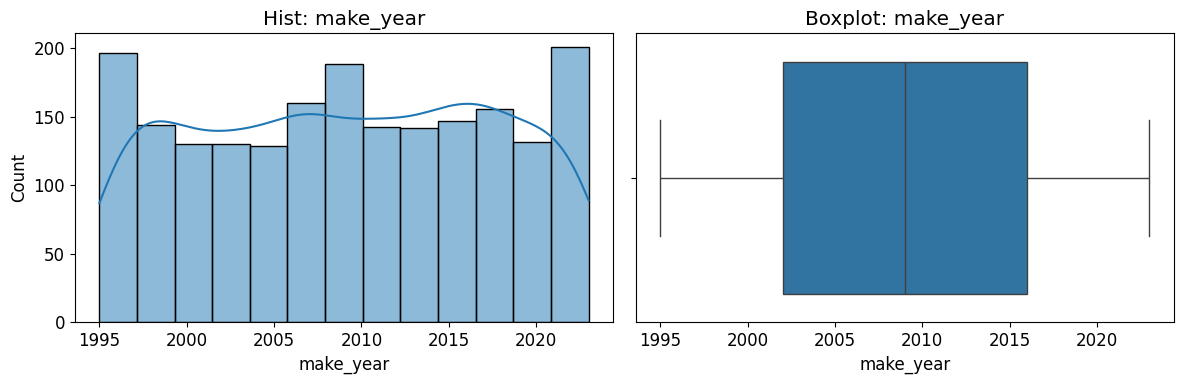

Столбец:  mileage_kmpl 

count    2000.000000
mean       18.018395
std         5.065829
min         5.000000
25%        14.570000
50%        18.005000
75%        21.382500
max        34.380000
Name: mileage_kmpl, dtype: float64
Выбросы:
Количество: 9
Процент: 0.45
Границы: 4.35 31.6
Первые 5 выбросов выше верхней границы: [31.62 31.86 32.   32.42 32.46]
5 максимальных значений: [32.46 32.47 33.07 33.44 34.38]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


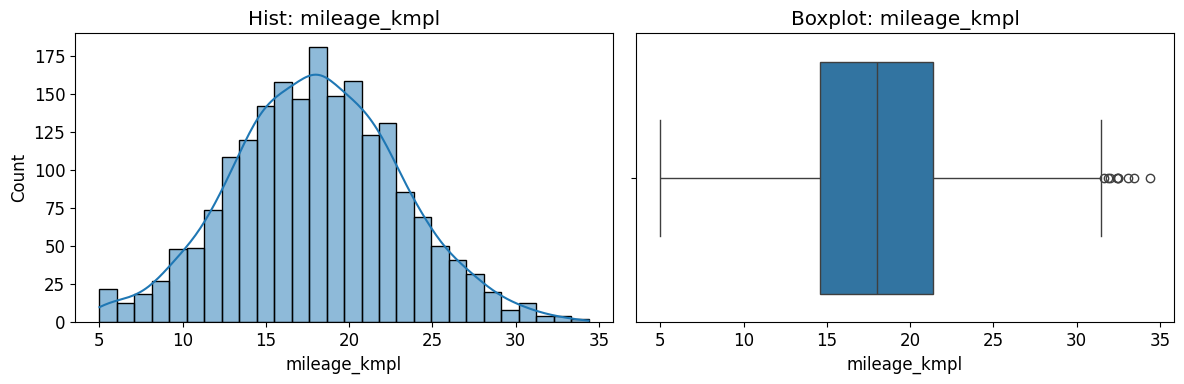

Столбец:  engine_cc 

count    2000.000000
mean     2276.900000
std      1297.392772
min       800.000000
25%      1200.000000
50%      1800.000000
75%      3000.000000
max      5000.000000
Name: engine_cc, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -1500.0 5700.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


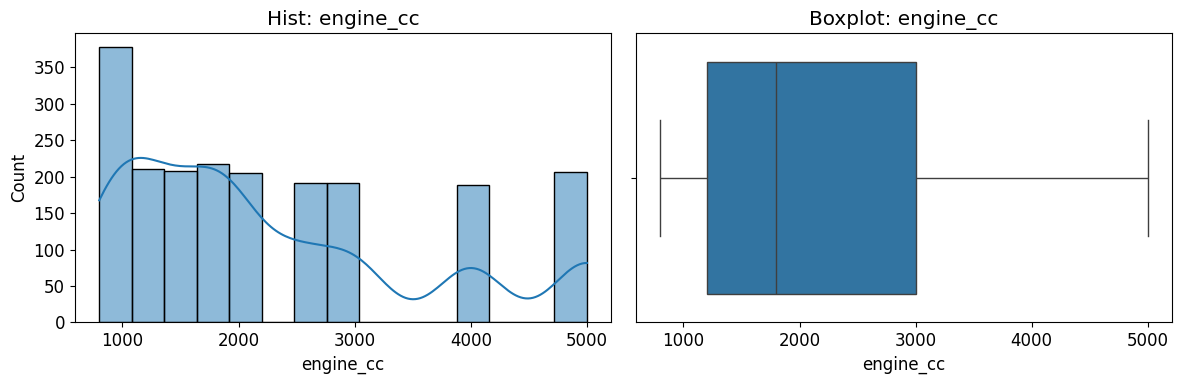

Столбец:  owner_count 

count    2000.00000
mean        3.01300
std         1.41804
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max         5.00000
Name: owner_count, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -1.0 7.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


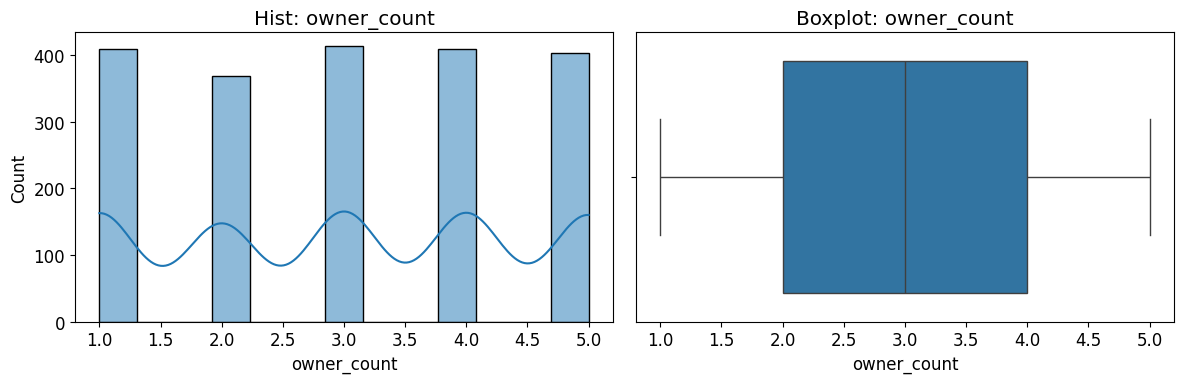

Столбец:  accidents_reported 

count    2000.000000
mean        0.509500
std         0.695091
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         4.000000
Name: accidents_reported, dtype: float64
Выбросы:
Количество: 27
Процент: 1.35
Границы: -1.5 2.5
Первые 5 выбросов выше верхней границы: [3 3 3 3 3]
5 максимальных значений: [3 3 3 4 4]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


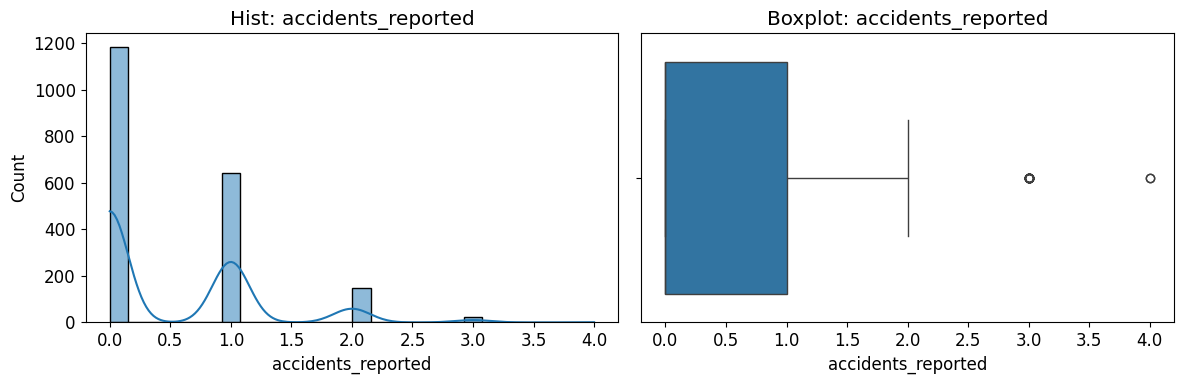

In [10]:
num_cols = ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']
for name, df in datasets.items():
    cols = [col for col in num_cols if col in df.columns]
    if cols:
        print("\n\n", name, "\n")
        for col in cols:
            print("Столбец: ", col, "\n")
            data_review(df, col)

<h4>Вывод</h4>
Большинство числовых признаков имеют категориальную природу, так как принимают ограниченное количество значений. Поэтому анализ их распределений и выбросов не отражает реальную структуру данных и не несёт большого количества полезной информации.

В текущих графиках наиболее ценным признаком является mileage_kmpl, поскольку он имеет непрерывное распределение. При этом на гистограмме виден рост количества автомобилей со значением до 8

<h3>Корреляции</h3>

In [11]:
def phik_corr_matrix(df, interval_cols=None, drop_cols=None):
    data = df.copy()
    
    if drop_cols:
        data = data.drop(columns=drop_cols, errors='ignore')
    
    corr = data.phik_matrix(interval_cols=interval_cols)
    sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
    print(corr)
    plt.show()
    
    return corr

train
                    make_year  mileage_kmpl  engine_cc  fuel_type  \
make_year            1.000000      0.047498   0.000000   0.042199   
mileage_kmpl         0.047498      1.000000   0.000000   0.047902   
engine_cc            0.000000      0.000000   1.000000   0.000000   
fuel_type            0.042199      0.047902   0.000000   1.000000   
owner_count          0.036453      0.013385   0.000000   0.027047   
brand                0.000000      0.022797   0.000000   0.018725   
transmission         0.000000      0.013520   0.000000   0.000000   
color                0.000000      0.000000   0.008417   0.034988   
service_history      0.052538      0.034144   0.004839   0.000000   
accidents_reported   0.000000      0.000000   0.000000   0.000000   
insurance_valid      0.047522      0.000000   0.006829   0.000000   
price_rub            0.413704      0.233398   0.656409   0.354523   
region               0.016617      0.000000   0.000000   0.044157   

                    owner_c

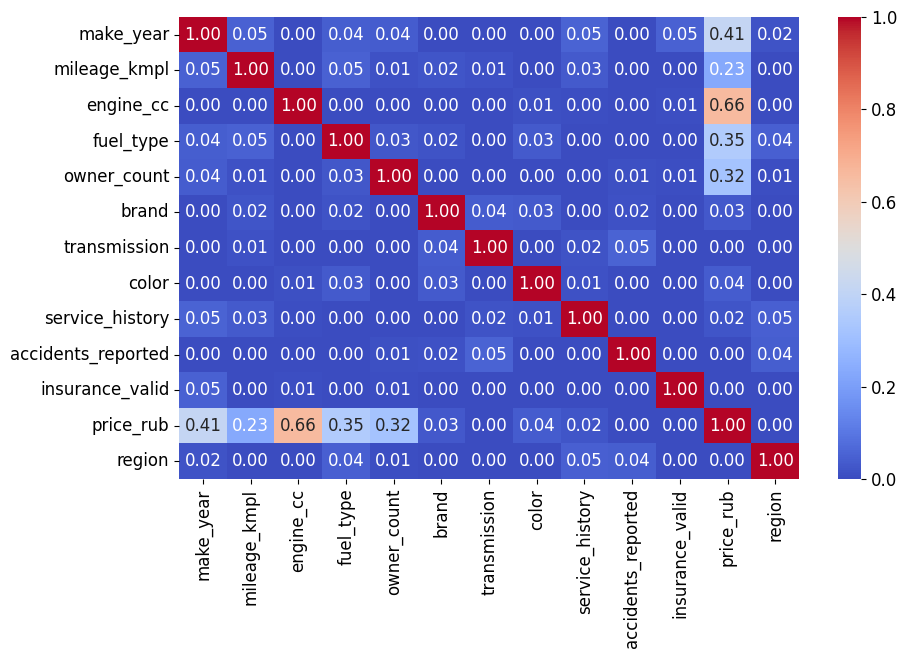

test
                    make_year  mileage_kmpl  engine_cc  fuel_type  \
make_year            1.000000      0.060114   0.000000   0.000000   
mileage_kmpl         0.060114      1.000000   0.000000   0.000000   
engine_cc            0.000000      0.000000   1.000000   0.108102   
fuel_type            0.000000      0.000000   0.108102   1.000000   
owner_count          0.000000      0.000000   0.000000   0.000000   
brand                0.086509      0.123459   0.000000   0.000000   
transmission         0.000000      0.000000   0.029569   0.000000   
color                0.000000      0.000000   0.000000   0.000000   
service_history      0.000000      0.057507   0.000000   0.000000   
accidents_reported   0.000000      0.000000   0.050762   0.008293   
insurance_valid      0.000000      0.031081   0.035940   0.011228   
price_rub            0.455245      0.282344   0.651095   0.395105   
region               0.000000      0.000000   0.000000   0.000000   

                    owner_co

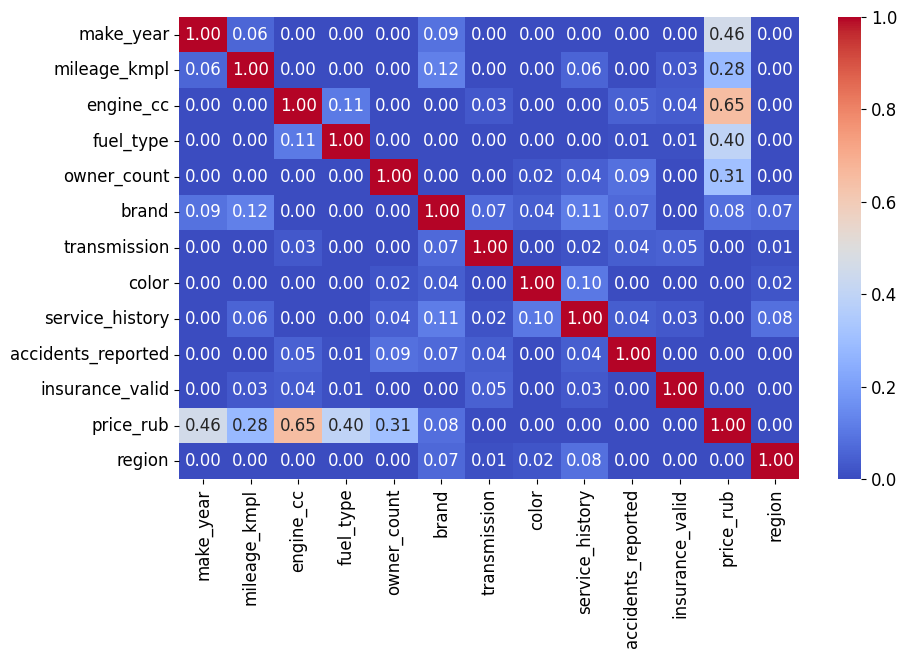

In [12]:
interval_cols = ['mileage_kmpl', 'price_rub']
for name, df in datasets.items():
    print(name)
    phik_corr_matrix(df=df, interval_cols=interval_cols)

<h4>Вывод по корреляционному анализу (phik)</h4>
<p>
Сильно коррелируют с целевым признаком price_rub: engine_cc, make_year, fuel_type, owner_count, mileage_kmpl
</p>
<p>
Слабую корреляцию с ценой показывают brand, color, transmission, service_history, insurance_valid, region 
</p>
<p>
Мультиколлинеарности между признаками нет 
</p>
<p>
Нужно проверить accidents_reported: phik с price_rub показал 0 в обеих выборках, что противоречит бизнес-логике 
</p>
<p>
Гипотеза о сильной корреляции mileage_kmpl с make_year и owner_count не подтвердилась 
</p>

In [13]:
for name, df in datasets.items():
    print(name)
    print(df.groupby('accidents_reported')['price_rub'].agg(['mean', 'median', 'count']))
    print()

train
                             mean    median  count
accidents_reported                                
0                   682189.220906  663068.0   4898
1                   686159.920050  665764.0   2414
2                   695517.147009  667827.0    585
3                   623618.736842  618016.0     95
4                   653916.500000  664356.5      6
5                   692658.000000  692658.0      2

test
                             mean    median  count
accidents_reported                                
0                   683489.805579  658872.0   1183
1                   659192.465839  628176.0    644
2                   670850.534247  644018.0    146
3                   744833.840000  761404.0     25
4                   965229.500000  965229.5      2



<b>Зависимости от колчества ДТП в данных действительно нет</b>

<h3>Рассмотрим как цена меняется в зависимости от бренда и региона</h3>

<Figure size 1000x500 with 0 Axes>

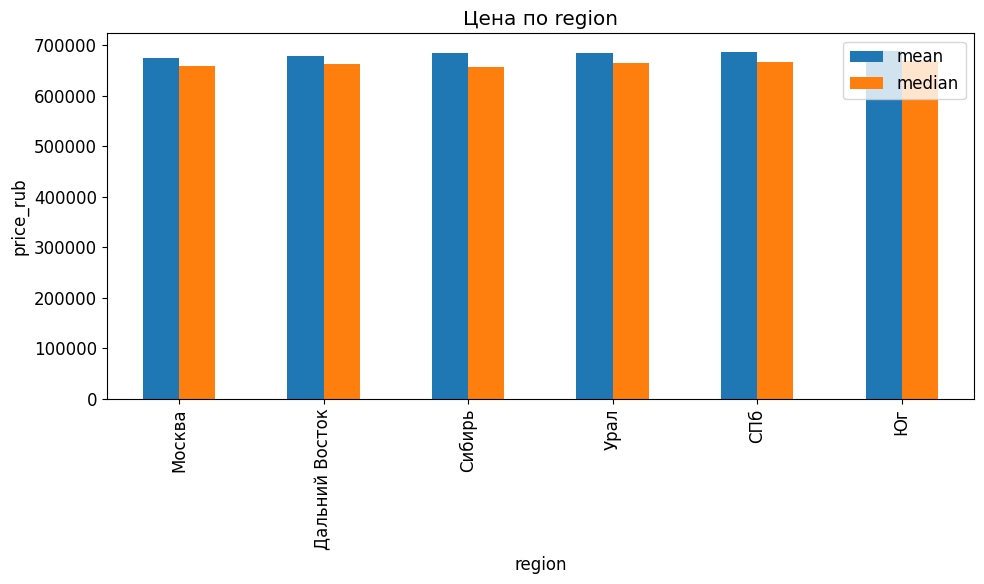

<Figure size 1000x500 with 0 Axes>

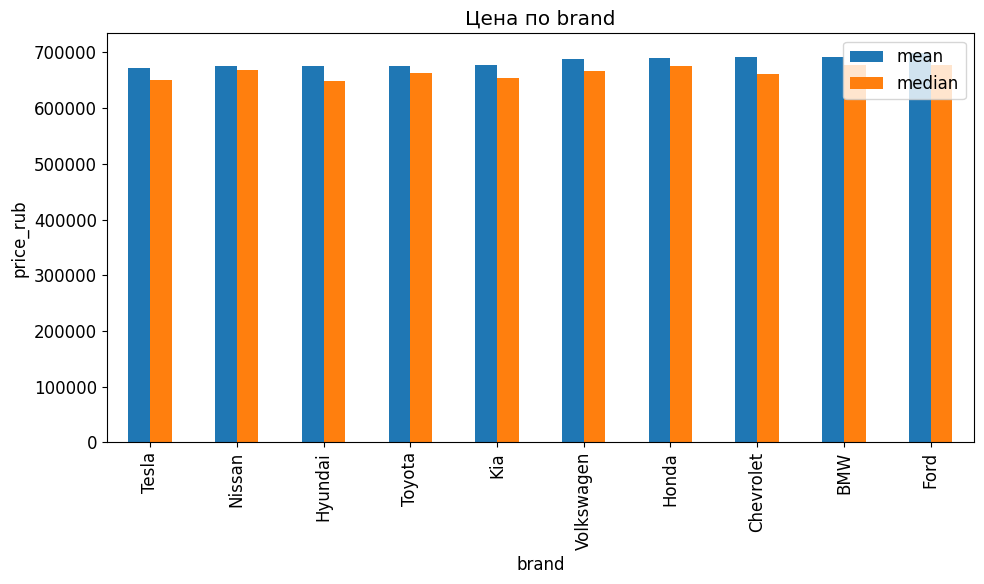

In [14]:
for col in ['region', 'brand']:
    plt.figure(figsize=(10, 5))
    agg = train.groupby(col, observed=True)['price_rub'].agg(['mean', 'median']).sort_values('mean')
    agg.plot(kind='bar')
    plt.title(f'Цена по {col}')
    plt.ylabel('price_rub')
    plt.tight_layout()
    plt.show()


<p>
Средняя и медиана нечильно расходятся у каждого признака, явно выделяющейся категории нет. Это подтверждаеет результаты phik-корреляции,
где brand и region показали слабую связь с price_rub 
</p>

<h2>Этап 3. Базовые модели: обучаем XGBoost, CatBoost и LightGBM дополнительно рассмотрим их время обучения</h2>

In [15]:
def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, fit_params={}):
    start = time.time()
    
    model.fit(X_train, y_train, **fit_params)
    duration = time.time() - start
    y_pred = model.predict(X_val)

    metrics = {"Model": model_name, "Duration": round(duration, 2)}

    for metric, func in scoring.items():
        value = func(y_val, y_pred)
        if metric in negative_sign:
            value = abs(value)
        metrics[metric] = value

    return model, metrics

In [16]:
def overpricing_rate(y_true, y_pred):
    error_ratio = (y_pred - y_true) / y_true
    return (error_ratio > 0.20).mean()

def underpricing_loss(y_true, y_pred):
    error_ratio = (y_pred - y_true) / y_true
    under_mask = error_ratio < -0.20
    return (y_true[under_mask] - y_pred[under_mask]).sum()

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

In [17]:
X = train[num_cols + cat_cols]
y = train['price_rub']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scoring = {
    'MAE': mean_absolute_error,
    'RMSE': rmse,
    'R2': r2_score,
    'Overpricing_Rate': overpricing_rate,
    'Underpricing_Loss': underpricing_loss,
}

negative_sign = ['MAE', 'RMSE', 'Overpricing_Rate', 'Underpricing_Loss']

model_cb = CatBoostRegressor(random_seed=RANDOM_STATE, verbose=0)
model_lgb = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
model_xgb = XGBRegressor(random_state=RANDOM_STATE, enable_categorical=True, tree_method='hist')

model_xgb, metrics_xgb = evaluate_model(model=model_xgb, model_name='XGBoost', X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val)
model_lgb, metrics_lgb = evaluate_model(model=model_lgb, model_name='LightGBM', X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val)
model_cb, metrics_cb = evaluate_model(model=model_cb, model_name='CatBoost', X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, fit_params={'cat_features': cat_cols})


metrics = pd.DataFrame([metrics_cb, metrics_xgb, metrics_lgb]).set_index('Model')

In [18]:
pd.set_option('display.float_format', '{:.2f}'.format)
metrics

,Duration,MAE,RMSE,R2,Overpricing_Rate,Underpricing_Loss
Model,,,,,,
CatBoost,20.30,79799.98,99560.54,0.85,0.14,17512995.37
XGBoost,0.11,88737.36,110463.76,0.82,0.15,24690265.88
LightGBM,1.40,82337.27,102691.03,0.84,0.14,19891460.60


<h4>Вывод по базовым моделям</h4>
<p>
CatBoost - лучший результат: MAE=79799, RMSE=99560, R2=0.85, Underpricing Loss=17.5млн, Overpricing Rate=0.14
</p
    >
<p>
LightGBM - результаты близкие к CatBoost, но при этом работает гораздо быстрее (1.51сек/34.14сек)
</p>
<p>
XGBoost - худший результат по всем метрикам при этом является самой быстрой моделью (0.12 сек).
</p>
<p>
Важно предпотение заказчика между точностью и скоростью: 
CatBoost точнее всех, но обучается на намного дольше; XGBoost быстрее всех,  но даёт наибольшие потери 
LightGBM - средний среди моделей с базовыми настройками - качество почти как у CatBoost при скорости в несколько раз выше
</p>
<p>
проведем подбор гиперпараметров через Optuna, который может изменить разницу между метриками
</p>

<h2>Этап 4. Гиперпараметры: Подбираем гиперпараметры используя Optuna</h2>

In [19]:
def objective_cb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_seed': RANDOM_STATE,
        'verbose': 0
    }
    model = CatBoostRegressor(**params, cat_features=cat_cols)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)
study_cb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cb.optimize(objective_cb, n_trials=30, show_progress_bar=True)
print('CatBoost best MAE:', study_cb.best_value)
print('CatBoost best params:', study_cb.best_params)
def objective_lgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0),
        'random_state': RANDOM_STATE,
        'verbose': -1
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train, categorical_feature=cat_cols)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)
study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)
print('LightGBM best MAE:', study_lgb.best_value)
print('LightGBM best params:', study_lgb.best_params)
def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0),
        'random_state': RANDOM_STATE,
        'enable_categorical': True,
        'tree_method': 'hist'
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)
study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)
print('XGBoost best MAE:', study_xgb.best_value)
print('XGBoost best params:', study_xgb.best_params)

[I 2026-08-13 19:52:13,997] A new study created in memory with name: no-name-cf265f9d-610f-40b1-8735-f9b309bbb320


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-13 19:53:08,144] Trial 0 finished with value: 80352.99058869426 and parameters: {'learning_rate': 0.023688639503640783, 'depth': 10, 'iterations': 1598, 'l2_leaf_reg': 6.387926357773329}. Best is trial 0 with value: 80352.99058869426.
[I 2026-08-13 19:53:14,856] Trial 1 finished with value: 79666.62474475497 and parameters: {'learning_rate': 0.014322493718230255, 'depth': 4, 'iterations': 587, 'l2_leaf_reg': 8.795585311974417}. Best is trial 1 with value: 79666.62474475497.
[I 2026-08-13 19:53:27,977] Trial 2 finished with value: 79996.40218513175 and parameters: {'learning_rate': 0.039913058785616795, 'depth': 8, 'iterations': 530, 'l2_leaf_reg': 9.72918866945795}. Best is trial 1 with value: 79666.62474475497.
[I 2026-08-13 19:53:35,524] Trial 3 finished with value: 79538.73917354712 and parameters: {'learning_rate': 0.06798962421591129, 'depth': 4, 'iterations': 772, 'l2_leaf_reg': 2.650640588680904}. Best is trial 3 with value: 79538.73917354712.
[I 2026-08-13 19:53:56,2

[I 2026-08-13 19:59:26,950] A new study created in memory with name: no-name-4de7deed-0231-4819-9d27-a294dab65c9c


[I 2026-08-13 19:59:26,946] Trial 29 finished with value: 79707.13120122677 and parameters: {'learning_rate': 0.023872376993346194, 'depth': 7, 'iterations': 507, 'l2_leaf_reg': 6.262851185270271}. Best is trial 5 with value: 79241.57035271177.
CatBoost best MAE: 79241.57035271177
CatBoost best params: {'learning_rate': 0.04091220574443785, 'depth': 4, 'iterations': 938, 'l2_leaf_reg': 4.297256589643226}


...

[I 2026-08-13 19:59:29,083] Trial 0 finished with value: 87703.89075395 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'num_leaves': 161, 'min_child_samples': 19, 'reg_alpha': 0.15599452877625744, 'reg_lambda': 0.05808362158736334}. Best is trial 0 with value: 87703.89075395.
[I 2026-08-13 19:59:29,733] Trial 1 finished with value: 87748.26242871361 and parameters: {'learning_rate': 0.07348118405270448, 'max_depth': 7, 'n_estimators': 1562, 'num_leaves': 24, 'min_child_samples': 98, 'reg_alpha': 0.8324426424759953, 'reg_lambda': 0.21233911855488502}. Best is trial 0 with value: 87703.89075395.
[I 2026-08-13 19:59:30,012] Trial 2 finished with value: 80494.50335324672 and parameters: {'learning_rate': 0.015199348301309814, 'max_depth': 4, 'n_estimators': 956, 'num_leaves': 144, 'min_child_samples': 46, 'reg_alpha': 0.2912291472857505, 'reg_lambda': 0.6118528986038505}. Best is trial 2 with value: 80494.50335324672.
[I 2026-08-13 19:59:30,4

[I 2026-08-13 19:59:40,011] A new study created in memory with name: no-name-45befcbd-6d66-4a45-af7d-bfe4156957f4


[I 2026-08-13 19:59:40,008] Trial 29 finished with value: 82911.55444943825 and parameters: {'learning_rate': 0.02615017495270542, 'max_depth': 6, 'n_estimators': 651, 'num_leaves': 105, 'min_child_samples': 16, 'reg_alpha': 0.6368972917609508, 'reg_lambda': 0.054960517307662826}. Best is trial 13 with value: 80067.01455475407.
LightGBM best MAE: 80067.01455475407
LightGBM best params: {'learning_rate': 0.024318368916764463, 'max_depth': 3, 'n_estimators': 799, 'num_leaves': 102, 'min_child_samples': 68, 'reg_alpha': 0.4195797838454444, 'reg_lambda': 0.3427992948383235}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-13 19:59:44,327] Trial 0 finished with value: 89522.25 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'gamma': 0.5986584882104518, 'reg_lambda': 1.5601864128641787, 'reg_alpha': 1.5599452118020811}. Best is trial 0 with value: 89522.25.
[I 2026-08-13 19:59:47,203] Trial 1 finished with value: 88874.7734375 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 9, 'n_estimators': 1402, 'gamma': 0.7080725807153198, 'reg_lambda': 0.2058449527521795, 'reg_alpha': 9.699098521920845}. Best is trial 1 with value: 88874.7734375.
[I 2026-08-13 19:59:47,519] Trial 2 finished with value: 82396.0078125 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 0.1834045180193887, 'reg_lambda': 3.0424224365529544, 'reg_alpha': 5.2475643210748135}. Best is trial 2 with value: 82396.0078125.
[I 2026-08-13 19:59:48,256] Trial 3 finished with value: 82854.0078125 and parameters: {'learning

<h4>Вывод по подбору гиперпараметров (Optuna)</h4>
<ul>
    <li>CatBoost - MAE 79241.57</li>
    <li>LightGBM - MAE 80067.01</li>
    <li>XGBoost - MAE 79949.24</li>
</ul>
<p>
Все три модели показывают близкий результат по средней ошибке. 
</p>
<p>
При этом CatBoost, несмотря на минимальный MAE, сильно уступает LightGBM и XGBoost в скорости обучения - разница составляет десятки раз. Учитывая, что разница в MAE у CatBoost по сравнению с другими моделями минимальна, а скорость обучения намного выше, в выборе итоговой модели стоит сравнить разницы в бизнес метриках и скорости обучения
</p>

<h2>Этап 5. Интерпретация и бизнес-анализ: проверяем основные признаки для предсказания используя SHAP, проверяем обосновано ли влияние признаков на target, свериваем ошибки модели с конкретными категориями машин</h2>

In [20]:
best_params_cb = study_cb.best_params
best_params_cb.update({'random_seed': RANDOM_STATE, 'verbose': 0})
model_cb_best = CatBoostRegressor(**best_params_cb)

best_params_lgb = study_lgb.best_params
best_params_lgb.update({'random_state': RANDOM_STATE, 'verbose': -1})
model_lgb_best = LGBMRegressor(**best_params_lgb)

best_params_xgb = study_xgb.best_params
best_params_xgb.update({'random_state': RANDOM_STATE, 'enable_categorical': True, 'tree_method': 'hist'})
model_xgb_best = XGBRegressor(**best_params_xgb)

model_cb_best, metrics_cb_best = evaluate_model(model=model_cb_best, model_name='CatBoost',X_train=X_train, y_train=y_train, 
                                                X_val=X_val, y_val=y_val, fit_params={'cat_features': cat_cols})

model_lgb_best, metrics_lgb_best = evaluate_model(model=model_lgb_best, model_name='LightGBM', X_train=X_train, y_train=y_train, 
                                                  X_val=X_val, y_val=y_val, fit_params={'categorical_feature': cat_cols})

model_xgb_best, metrics_xgb_best = evaluate_model(model=model_xgb_best, model_name='XGBoost', X_train=X_train, y_train=y_train, 
                                                  X_val=X_val, y_val=y_val)

metrics_tuned = pd.DataFrame([metrics_cb_best, metrics_xgb_best, metrics_lgb_best]).set_index('Model')
metrics_tuned

,Duration,MAE,RMSE,R2,Overpricing_Rate,Underpricing_Loss
Model,,,,,,
CatBoost,8.77,79241.57,99016.06,0.86,0.13,17371608.99
XGBoost,0.52,79949.24,100120.11,0.85,0.14,19366705.08
LightGBM,0.13,80067.01,100287.77,0.85,0.14,19086026.80


<h3>Вывод по бизнес-метрикам</h3>
<p>
Выбор модели - CatBoost, так как приоритет дан на бизнес-метрикам: CatBoost показывает наименьший Overpricing Rate и наименьший Underpricing Loss 17.37 млн руб. экономя около 2 млн руб. по сравнению с конкурентами
</p>
<p>
При этом стоит учесть, что скорость обучения CatBoost кратно меньше остальных моделей (10.50 сек / 0.43 сек у XGBoost / 0.13 сек у LightGBM. 
Для данной задачи критична точность и минимизация финансовых рисков, эта разница в скорости обучения не является основным фактором
</p>

In [21]:
def create_SHAP(model, df, model_name):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(df)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, df, show=False)
    plt.title(f"SHAP Summary Plot: {model_name}")
    plt.tight_layout()
    plt.show()

    return shap_values

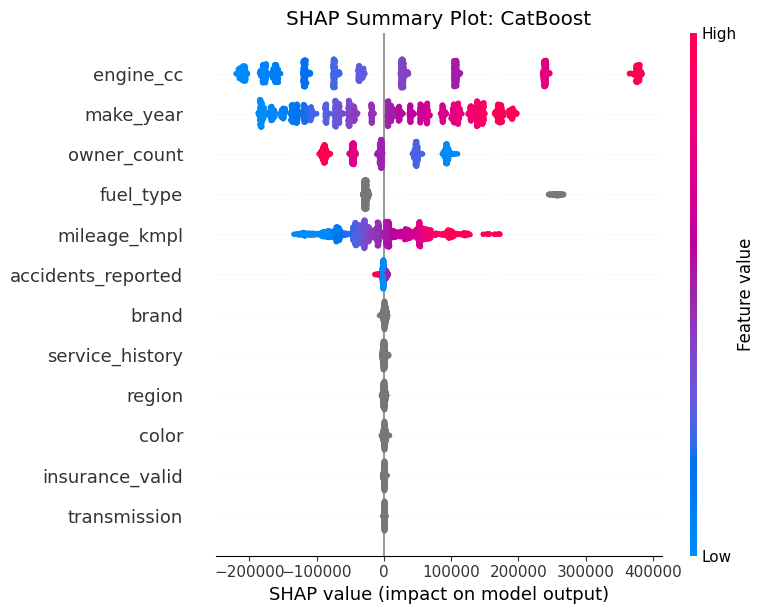

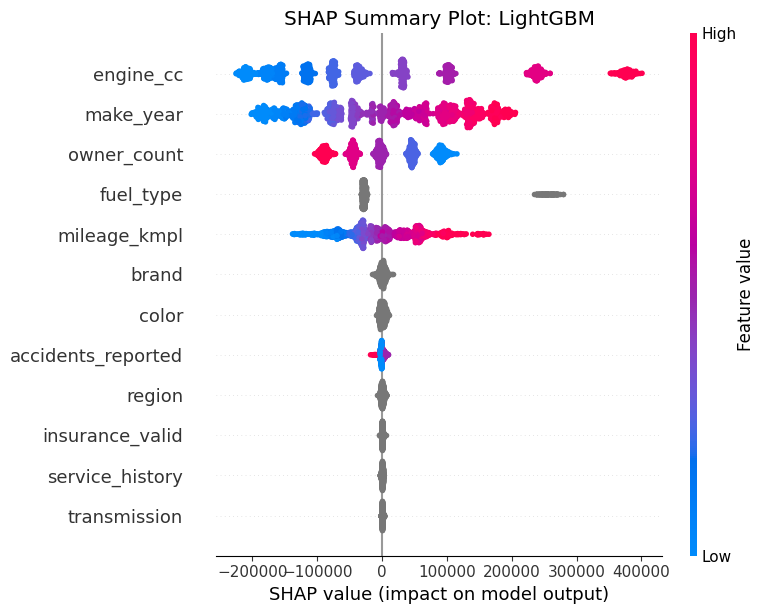

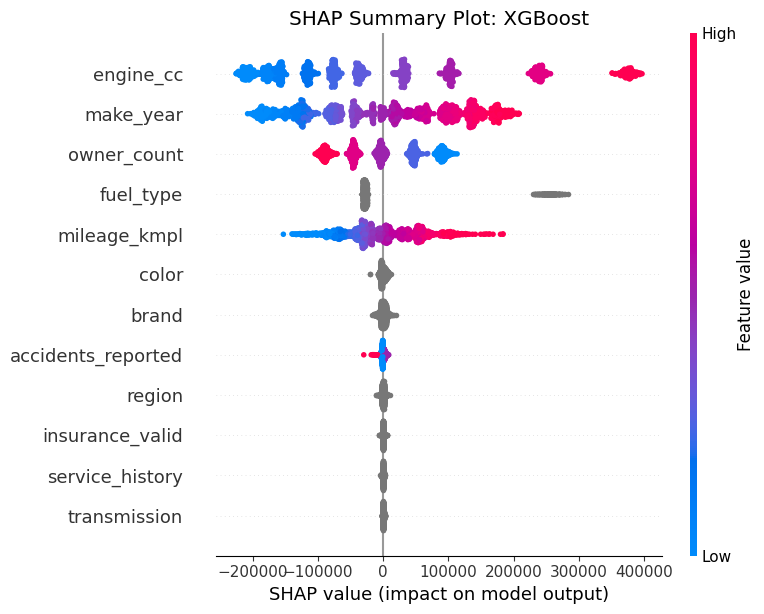

In [22]:
shap_values_cb = create_SHAP(model_cb_best, X_val, model_name='CatBoost')
shap_values_lgb = create_SHAP(model_lgb_best, X_val, model_name='LightGBM')
shap_values_xgb = create_SHAP(model_xgb_best, X_val, model_name='XGBoost')

<h3>Вывод по SHAP-анализу</h3>
<p>
1. Все 3 модели показывают схожую картину, одинаково выделяя вклад признаков в 
предсказания. Топ-5 признаков для всех моделей один и тот же: engine_cc, make_year, 
owner_count, fuel_type, mileage_kmpl.
</p>
<p>
2. В основном выводы совпадают с бизнес-логикой: характеристики машины вроде мощности 
мотора, топлива, года выпуска вносят основной вклад, их изменение прямо отражает 
изменение цены. Однако связь с mileage_kmpl - признаком, который согласно описанию 
данных к заданию - "Пробег (км), реальный физический износ автомобиля" - почему-то 
несёт с ценой прямо пропорциональную связь, хотя связь должна быть обратной. Либо это 
неточность в формулировке признака, либо ошибка данных.
</p>
<p>
3. Специфические признаки color, insurance_valid, brand, region, service_history и transmission, показывают SHAP-значения около нуля 
во всех трёх моделях - модель почти не использует их в предсказании, гипотеза о том, что признаки отражают поведеньческую часть в формировании цены не подтвердилась
</p>

In [23]:
def mae_by_category(model, X, y, col):
    categories = X[col].unique()
    preds = model.predict(X)
    mae_per_cat = {}

    for cat in categories:
        mask = X[col] == cat
        mae_per_cat[cat] = mean_absolute_error(y[mask], preds[mask])

    return mae_per_cat
def business_by_category(model, X, y, col):
    preds = model.predict(X)
    over, under = {}, {}
    for cat in X[col].unique():
        mask = X[col] == cat
        over[cat] = overpricing_rate(y[mask].values, preds[mask])
        under[cat] = underpricing_loss(y[mask].values, preds[mask])
    return over, under

In [24]:
mae_brand_cb = mae_by_category(model_cb_best, X_val, y_val, 'brand')
mae_brand_lgb = mae_by_category(model_lgb_best, X_val, y_val, 'brand')
mae_brand_xgb = mae_by_category(model_xgb_best, X_val, y_val, 'brand')
over_brand_cb, under_brand_cb = business_by_category(model_cb_best, X_val, y_val, 'brand')

mae_brand_df = pd.DataFrame({
    'CatBoost_MAE': mae_brand_cb,
    'LightGBM_MAE': mae_brand_lgb,
    'XGBoost_MAE': mae_brand_xgb,
    'CatBoost_Overpricing_Rate': over_brand_cb,
    'CatBoost_Underpricing_Loss': under_brand_cb,
})
print("MAE и бизнес-метрики по брендам:")
display(mae_brand_df)

mae_region_cb = mae_by_category(model_cb_best, X_val, y_val, 'region')
mae_region_lgb = mae_by_category(model_lgb_best, X_val, y_val, 'region')
mae_region_xgb = mae_by_category(model_xgb_best, X_val, y_val, 'region')
over_region_cb, under_region_cb = business_by_category(model_cb_best, X_val, y_val, 'region')

mae_region_df = pd.DataFrame({
    'CatBoost_MAE': mae_region_cb,
    'LightGBM_MAE': mae_region_lgb,
    'XGBoost_MAE': mae_region_xgb,
    'CatBoost_Overpricing_Rate': over_region_cb,
    'CatBoost_Underpricing_Loss': under_region_cb,
})
print("MAE и бизнес-метрики по регионам:")
display(mae_region_df)

MAE и бизнес-метрики по брендам:


,CatBoost_MAE,LightGBM_MAE,XGBoost_MAE,CatBoost_Overpricing_Rate,CatBoost_Underpricing_Loss
Volkswagen,76047.94,77242.84,76730.17,0.16,1992977.79
Honda,71371.80,72889.75,73887.47,0.12,514809.54
Tesla,85972.29,87290.62,88157.84,0.15,2314765.21
Chevrolet,71696.22,72187.07,72836.09,0.12,1630509.54
Kia,84148.39,83819.79,84256.04,0.11,2095676.95
Nissan,73641.47,75779.76,74516.02,0.11,1621125.95
Toyota,85739.69,86692.78,85478.77,0.17,1904838.30
Hyundai,78025.77,77722.53,77571.71,0.12,1342707.36
Ford,77883.77,79489.68,78662.04,0.14,1222073.68
BMW,86494.15,86385.73,86369.37,0.11,2732124.66


MAE и бизнес-метрики по регионам:


,CatBoost_MAE,LightGBM_MAE,XGBoost_MAE,CatBoost_Overpricing_Rate,CatBoost_Underpricing_Loss
Дальний Восток,80640.14,81050.18,81342.11,0.09,3087526.84
Москва,76183.92,76637.12,76747.42,0.12,2657172.11
Урал,81465.29,83141.88,82638.75,0.15,1756412.44
Сибирь,80381.59,82386.18,82170.35,0.15,2333847.98
Юг,78039.02,77336.88,77017.84,0.14,3797071.50
СПб,78661.45,79920.84,79900.43,0.13,3739578.12


<h4>Вывод</h4>
<p>
Все три модели показывают схожие результаты - для каждого бренда и региона MAE у всех моделей близки разброс не более 2%
</p>
<p>
Анализ бизнес-метрик показал категории с наибольшим Overpricing Rate: регионы Урал, Сибирь, Юг и марки Toyota, Volkswagen, Tesla. При этом Underpricing Loss по этим категориям ведёт себя неоднозначно: у Урала и Сибири он ниже среднего, а у Юга самый высокий средирегионов. Проверим количество объектов в каждой категории, чтобы понять, не связаны ли отклонения с малым размером
</p>
<p>
Между категориями есть заметное отклонение: по брендам MAE от 71372 руб. до 86494 руб. в абсолютных значениях рассмотрим разброс относительно цены
</p>


рассмотрим сколько в среднем теряем с каждой сделки это поможет построить связь с количеством объектов

In [25]:
region_counts = X_val['region'].value_counts()
brand_counts = X_val['brand'].value_counts()

mae_region_df['Loss_per_deal'] = mae_region_df['CatBoost_Underpricing_Loss'] / region_counts
mae_brand_df['Loss_per_deal'] = mae_brand_df['CatBoost_Underpricing_Loss'] / brand_counts

display(mae_region_df[['CatBoost_Overpricing_Rate', 'CatBoost_Underpricing_Loss', 'Loss_per_deal']])
display(mae_brand_df[['CatBoost_Overpricing_Rate', 'CatBoost_Underpricing_Loss', 'Loss_per_deal']])

,CatBoost_Overpricing_Rate,CatBoost_Underpricing_Loss,Loss_per_deal
Дальний Восток,0.09,3087526.84,11784.45
Москва,0.12,2657172.11,10671.37
Урал,0.15,1756412.44,6363.81
Сибирь,0.15,2333847.98,9224.70
Юг,0.14,3797071.50,12959.29
СПб,0.13,3739578.12,14005.91


,CatBoost_Overpricing_Rate,CatBoost_Underpricing_Loss,Loss_per_deal
Volkswagen,0.16,1992977.79,11520.10
Honda,0.12,514809.54,3900.07
Tesla,0.15,2314765.21,14201.01
Chevrolet,0.12,1630509.54,10254.78
Kia,0.11,2095676.95,12548.96
Nissan,0.11,1621125.95,9536.04
Toyota,0.17,1904838.30,12531.83
Hyundai,0.12,1342707.36,8088.60
Ford,0.14,1222073.68,8313.43
BMW,0.11,2732124.66,15977.34


Рассмотри есть ли связь ошибок со средней ценой в категории

In [26]:
mean_price_by_brand = train.groupby('brand', observed=True)['price_rub'].mean()
mae_brand = (mae_brand_df['CatBoost_MAE'] / mean_price_by_brand * 100).sort_values(ascending=False)
print("MAE от средней цены бренда:")
print(mae_brand)
mean_price_by_region = train.groupby('region', observed=True)['price_rub'].mean()
mae_region = (mae_region_df['CatBoost_MAE'] / mean_price_by_region * 100).sort_values(ascending=False)
print("MAE от средней цены в регионе:")
print(mae_region)


MAE от средней цены бренда:
Tesla        12.79
Toyota       12.69
BMW          12.50
Kia          12.42
Hyundai      11.55
Ford         11.14
Volkswagen   11.06
Nissan       10.91
Chevrolet    10.37
Honda        10.34
dtype: float64
MAE от средней цены в регионе:
Урал             11.88
Дальний Восток   11.87
Сибирь           11.73
СПб              11.46
Юг               11.32
Москва           11.29
dtype: float64


<p>
Урал имеет высокий MAE (11.88%) и самый высокий Overpricing Rate (0.15), но при этом самый низкий Loss_per_deal риск в основном в переплатах, а не в упущенной выгоде. СПб имеет средний MAE, но самый высокий Loss_per_deal здесь риск в упущенной выгоде при заниженных ценах.
</p>
<p>
BMW и Tesla стабильно показывают повышенные значения MAE и Loss_per_deal - наиболее рискованные марки. Toyota показывает высокий Overpricing Rate (0.17) при среднем Loss_per_deal - риск сосредоточен в переплатах. Honda - самая стабильная и предсказуемая марка по всем показателям.
</p>

<h2>Этап 6. Финальная проверка тестируем модель на тестовых данных проверяем выполняются ли критерии заказчика</h2>

In [27]:
best_params_cb = study_cb.best_params
best_params_cb.update({'random_seed': RANDOM_STATE, 'verbose': 0})

final_model = CatBoostRegressor(**best_params_cb, cat_features=cat_cols)
final_model.fit(X, y)  

X_test_final = test[num_cols + cat_cols]
y_test_final = test['price_rub']

test_preds = final_model.predict(X_test_final)

test_mae = mean_absolute_error(y_test_final, test_preds)
test_rmse = rmse(y_test_final, test_preds)
test_r2 = r2_score(y_test_final, test_preds)
test_overpricing = overpricing_rate(y_test_final.values, test_preds)
test_underpricing = underpricing_loss(y_test_final.values, test_preds)

print("Метрики на финальном тесте (CatBoostRegressor)")
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("R2:", test_r2)
print("Overpricing Rate:", test_overpricing)
print("Underpricing Loss:", test_underpricing)

Метрики на финальном тесте (CatBoostRegressor)
MAE: 75247.90623686975
RMSE: 94586.80661103375
R2: 0.8753922017300141
Overpricing Rate: 0.1335
Underpricing Loss: 19568412.357104763


<h4>Вывод по финальной проверке</h4>
<p>
Разница между valid и test по MAE минимальна переобучения нет, модель показала на тесте даже более лучший результат. Overpricing Rate практически не изменился (13%/13.35%). Критерии заказчика по точности и бизнес метрикам выполняются, модель готова к внедрению
</p>

<h2>АНАЛИТИЧЕСКАЯ ЗАПИСКА </h2>

<p>1. Рекомендованная модель: CatBoostRegressor с гиперпараметрами (learning_rate = 0.041, depth = 4, iterations = 938, l2_leaf_reg ≈ 4.30). Выбран CatBoost, так как для заказчика приоритет на минимизации финансовых рисков, не смотря на то что модель обучается в десятки раз дольше аналогов. CatBoost даёт лучшие показатели по бизнес-метрикам</p>

<p>2. Точность оценки: на тестовой выборке MAE = 75248 руб,. Коэффициент детерминации R² = 0.875 модель объясняет 87.5% дисперсии цены, что подтверждает высокую надёжность прогнозов</p>

<p>3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне 13.35%. Это позволяет стартапу сохранять маржинальность при выкупе.</p>

<p>4. Упущенная выгода: можем терять до 19.6 млн руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента</p>

<p>5. Зоны риска: модель наиболее нестабильна в регионе Урал и Сибирь и на марках Tesla, Toyota и BMW. Отклонение заметно, но не является аномальным и не указывает на явные неточности модели</p>

<p>6. Гиперпараметры для фиксации при интеграции: <code>learning_rate = 0.0409</code>, <code>depth = 4</code>, <code>iterations = 938</code>, <code>l2_leaf_reg = 4.297</code>, <code>random_seed=42</code></p>
